# Lab 3
This instance of lab is divided into 2 parts; Part A: Advanced Data Analytics and Part B: PCA

# Part A: Advanced Data Analytics
In this part we do advanced data analytical process on the Berlin Airbnb dataset.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

url =  'https://raw.githubusercontent.com/bobbhai69/ITEC203_Lab_repo/refs/heads/main/Lab2/Data/listings_berlin.csv'
df = pd.read_csv(url)
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,1944,bright & airy Pberg/Mitte 3 months or more,2164,Lulah,Mitte,Brunnenstr. Nord,52.54433,13.39761,Private room,28,60,18,2018-11-11,0.21,3,101
1,2015,Berlin-Mitte Value! Quiet courtyard/very central,2217,Ion,Mitte,Brunnenstr. Süd,52.53305,13.40394,Entire home/apt,74,90,141,2020-04-03,2.20,6,357
2,3176,Fabulous Flat in great Location,3718,Britta,Pankow,Prenzlauer Berg Südwest,52.53471,13.41810,Entire home/apt,90,62,147,2017-03-20,1.14,1,254
3,3309,BerlinSpot Schöneberg near KaDeWe,4108,Jana,Tempelhof - Schöneberg,Schöneberg-Nord,52.49884,13.34940,Private room,29,7,27,2018-08-16,0.28,1,285
4,6883,Stylish East Side Loft in Center with AC & 2 b...,16149,Steffen,Friedrichshain-Kreuzberg,Frankfurter Allee Süd FK,52.51163,13.45289,Entire home/apt,79,7,135,2021-01-02,1.02,1,0


In [ ]:
# Checking the number of null values in all the columns
df.isnull().sum()

,0
id,0
name,30
host_id,0
host_name,12
neighbourhood_group,0
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0


In [ ]:
# Distinguising categorical and numerical columns
categorical = [var for var in df.columns if df[var].dtype=='O']
numerical = [var for var in df.columns if df[var].dtype!='O']

print(f'these are the categoricl columns: {categorical}')
print(f'these are the numerical columns: {numerical}')

these are the categoricl columns: ['name', 'host_name', 'neighbourhood_group', 'neighbourhood', 'room_type', 'last_review']
these are the numerical columns: ['id', 'host_id', 'latitude', 'longitude', 'price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365']


> We then remove the categorical column with missing values.


In [ ]:
# Removing 'last-review' column in the cleaned dataset
df_cleaned = df.drop(['last_review'], axis=1)

# Filling up reviews_per_month column with mean
df_cleaned['reviews_per_month'] = df_cleaned['reviews_per_month'].fillna(df_cleaned['reviews_per_month'].mean())

# Removing missing values from other columns
df_cleaned = df_cleaned.dropna()

# 1. Looking for correlation
We now compute the standard correlation coefficient ( also called Pearson's r) between every pair of attributes.

In [ ]:
# Label encoding the categorical columns
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
label_encoder = {}
for column in df_cleaned.columns:
    if df_cleaned[column].dtype == 'object':
        le = LabelEncoder()
        df_cleaned[column] = le.fit_transform(df_cleaned[column])
        label_encoder[column] = le

print(df_cleaned.head())

     id   name  host_id  host_name  neighbourhood_group  neighbourhood  \
0  1944  17382     2164       3028                    4             17   
1  2015   3177     2217       2108                    4             18   
2  3176   7630     3718        718                    6            100   
3  3309   3209     4108       2215                   10            112   
4  6883  15104    16149       4634                    1             33   

   latitude  longitude  room_type  price  minimum_nights  number_of_reviews  \
0  52.54433   13.39761          2     28              60                 18   
1  52.53305   13.40394          0     74              90                141   
2  52.53471   13.41810          0     90              62                147   
3  52.49884   13.34940          2     29               7                 27   
4  52.51163   13.45289          0     79               7                135   

   reviews_per_month  calculated_host_listings_count  availability_365  
0      

In [ ]:
# For us to compute the correlation we would need scaled, standardized data
scaler = StandardScaler()
df_scaled = df_cleaned.copy()
df_scaled[numerical] = scaler.fit_transform(df_scaled[numerical])
df_scaled.head()


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
0,-1.686549,17382,-0.868529,3028,4,17,1.052624,-0.111662,2,-0.332506,1.511113,-0.075544,-0.397849,-0.018037,0.074786
1,-1.686544,3177,-0.868529,2108,4,18,0.704475,-0.011171,0,0.004775,2.402101,2.449418,1.157384,0.367518,2.079494
2,-1.686466,7630,-0.868515,718,6,100,0.755709,0.213623,0,0.122091,1.570512,2.572587,0.328968,-0.275074,1.272912
3,-1.686457,3209,-0.868511,2215,10,112,-0.351394,-0.877010,2,-0.325174,-0.062967,0.109210,-0.343143,-0.275074,1.515670
4,-1.686218,15104,-0.868399,4634,1,33,0.043361,0.765925,0,0.041436,-0.062967,2.326249,0.235185,-0.275074,-0.716134


In [ ]:
# Normalizing the data (min-max scaling)
min_max_scaler = MinMaxScaler()
df_normalized = df_cleaned.copy()
df_normalized[numerical] = min_max_scaler.fit_transform(df_normalized[numerical])
df_normalized.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
0,0.000000,17382,0.000001,3028,4,17,0.646311,0.455091,2,0.003500,0.052538,0.029032,0.002120,0.026667,0.276712
1,0.000001,3177,0.000002,2108,4,18,0.610619,0.464678,0,0.009250,0.079252,0.227419,0.023214,0.066667,0.978082
2,0.000024,7630,0.000005,718,6,100,0.615871,0.486126,0,0.011250,0.054319,0.237097,0.011978,0.000000,0.695890
3,0.000027,3209,0.000006,2215,10,112,0.502373,0.382070,2,0.003625,0.005343,0.043548,0.002862,0.000000,0.780822
4,0.000097,15104,0.000035,4634,1,33,0.542843,0.538820,0,0.009875,0.005343,0.217742,0.010706,0.000000,0.000000


In [ ]:
# Computing standard correlation coefficient between every pair of attributes
correlation_matrix_scaled = df_scaled.corr()
correlation_matrix_scaled

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
id,1.000000,-0.017167,0.554107,-0.000458,0.021179,-0.070879,0.016293,-0.008226,-0.034830,0.052325,-0.021779,-0.296690,0.062149,0.178082,0.125187
name,-0.017167,1.000000,-0.002653,0.014624,0.011438,-0.000622,-0.020702,-0.005687,0.063284,-0.016054,-0.011843,-0.014391,-0.014484,-0.069370,-0.001684
host_id,0.554107,-0.002653,1.000000,-0.020164,0.033502,-0.070008,0.022821,-0.034898,-0.002062,0.048953,-0.020037,-0.137058,0.091197,0.170895,0.184328
host_name,-0.000458,0.014624,-0.020164,1.000000,-0.024250,0.005528,-0.000345,0.004106,-0.004495,-0.002979,0.008258,0.005279,0.013410,-0.056643,-0.006747
neighbourhood_group,0.021179,0.011438,0.033502,-0.024250,1.000000,0.084799,-0.168918,0.021031,-0.018260,-0.009223,-0.002080,-0.018017,-0.003042,0.079047,0.051762
neighbourhood,-0.070879,-0.000622,-0.070008,0.005528,0.084799,1.000000,-0.119297,-0.170982,0.050006,-0.023482,-0.020974,-0.014547,-0.027649,-0.060620,-0.078293
latitude,0.016293,-0.020702,0.022821,-0.000345,-0.168918,-0.119297,1.000000,-0.138440,-0.024820,0.016067,0.008833,0.032552,0.022177,0.013681,0.021120
longitude,-0.008226,-0.005687,-0.034898,0.004106,0.021031,-0.170982,-0.138440,1.000000,-0.002199,-0.024394,-0.028308,-0.018421,-0.014719,-0.044324,-0.071985
room_type,-0.034830,0.063284,-0.002062,-0.004495,-0.018260,0.050006,-0.024820,-0.002199,1.000000,-0.170134,-0.100795,-0.060407,-0.067298,-0.021645,-0.099323
price,0.052325,-0.016054,0.048953,-0.002979,-0.009223,-0.023482,0.016067,-0.024394,-0.170134,1.000000,-0.009299,0.016242,0.028678,0.058697,0.134676


In [ ]:
# correlation with the normalized data to check for inconsistencies
correlation_matrix_normalized = df_normalized.corr()
correlation_matrix_normalized

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
id,1.000000,-0.017167,0.554107,-0.000458,0.021179,-0.070879,0.016293,-0.008226,-0.034830,0.052325,-0.021779,-0.296690,0.062149,0.178082,0.125187
name,-0.017167,1.000000,-0.002653,0.014624,0.011438,-0.000622,-0.020702,-0.005687,0.063284,-0.016054,-0.011843,-0.014391,-0.014484,-0.069370,-0.001684
host_id,0.554107,-0.002653,1.000000,-0.020164,0.033502,-0.070008,0.022821,-0.034898,-0.002062,0.048953,-0.020037,-0.137058,0.091197,0.170895,0.184328
host_name,-0.000458,0.014624,-0.020164,1.000000,-0.024250,0.005528,-0.000345,0.004106,-0.004495,-0.002979,0.008258,0.005279,0.013410,-0.056643,-0.006747
neighbourhood_group,0.021179,0.011438,0.033502,-0.024250,1.000000,0.084799,-0.168918,0.021031,-0.018260,-0.009223,-0.002080,-0.018017,-0.003042,0.079047,0.051762
neighbourhood,-0.070879,-0.000622,-0.070008,0.005528,0.084799,1.000000,-0.119297,-0.170982,0.050006,-0.023482,-0.020974,-0.014547,-0.027649,-0.060620,-0.078293
latitude,0.016293,-0.020702,0.022821,-0.000345,-0.168918,-0.119297,1.000000,-0.138440,-0.024820,0.016067,0.008833,0.032552,0.022177,0.013681,0.021120
longitude,-0.008226,-0.005687,-0.034898,0.004106,0.021031,-0.170982,-0.138440,1.000000,-0.002199,-0.024394,-0.028308,-0.018421,-0.014719,-0.044324,-0.071985
room_type,-0.034830,0.063284,-0.002062,-0.004495,-0.018260,0.050006,-0.024820,-0.002199,1.000000,-0.170134,-0.100795,-0.060407,-0.067298,-0.021645,-0.099323
price,0.052325,-0.016054,0.048953,-0.002979,-0.009223,-0.023482,0.016067,-0.024394,-0.170134,1.000000,-0.009299,0.016242,0.028678,0.058697,0.134676


In [ ]:
corr_matrix = correlation_matrix_normalized.copy()
corr_matrix.style.background_gradient(cmap='coolwarm')

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
id,1.000000,-0.017167,0.554107,-0.000458,0.021179,-0.070879,0.016293,-0.008226,-0.034830,0.052325,-0.021779,-0.296690,0.062149,0.178082,0.125187
name,-0.017167,1.000000,-0.002653,0.014624,0.011438,-0.000622,-0.020702,-0.005687,0.063284,-0.016054,-0.011843,-0.014391,-0.014484,-0.069370,-0.001684
host_id,0.554107,-0.002653,1.000000,-0.020164,0.033502,-0.070008,0.022821,-0.034898,-0.002062,0.048953,-0.020037,-0.137058,0.091197,0.170895,0.184328
host_name,-0.000458,0.014624,-0.020164,1.000000,-0.024250,0.005528,-0.000345,0.004106,-0.004495,-0.002979,0.008258,0.005279,0.013410,-0.056643,-0.006747
neighbourhood_group,0.021179,0.011438,0.033502,-0.024250,1.000000,0.084799,-0.168918,0.021031,-0.018260,-0.009223,-0.002080,-0.018017,-0.003042,0.079047,0.051762
neighbourhood,-0.070879,-0.000622,-0.070008,0.005528,0.084799,1.000000,-0.119297,-0.170982,0.050006,-0.023482,-0.020974,-0.014547,-0.027649,-0.060620,-0.078293
latitude,0.016293,-0.020702,0.022821,-0.000345,-0.168918,-0.119297,1.000000,-0.138440,-0.024820,0.016067,0.008833,0.032552,0.022177,0.013681,0.021120
longitude,-0.008226,-0.005687,-0.034898,0.004106,0.021031,-0.170982,-0.138440,1.000000,-0.002199,-0.024394,-0.028308,-0.018421,-0.014719,-0.044324,-0.071985
room_type,-0.034830,0.063284,-0.002062,-0.004495,-0.018260,0.050006,-0.024820,-0.002199,1.000000,-0.170134,-0.100795,-0.060407,-0.067298,-0.021645,-0.099323
price,0.052325,-0.016054,0.048953,-0.002979,-0.009223,-0.023482,0.016067,-0.024394,-0.170134,1.000000,-0.009299,0.016242,0.028678,0.058697,0.134676


Now we check how much each attribute correlates with 'number_of_reviews' in a descending order.

In [ ]:
# Checking how much each attribute correlates with 'number_of_reviews' in a descendig order
corr_matrix['number_of_reviews'].sort_values(ascending=False)

,number_of_reviews
number_of_reviews,1.000000
reviews_per_month,0.576097
availability_365,0.208712
latitude,0.032552
calculated_host_listings_count,0.017294
price,0.016242
host_name,0.005279
name,-0.014391
neighbourhood,-0.014547
neighbourhood_group,-0.018017


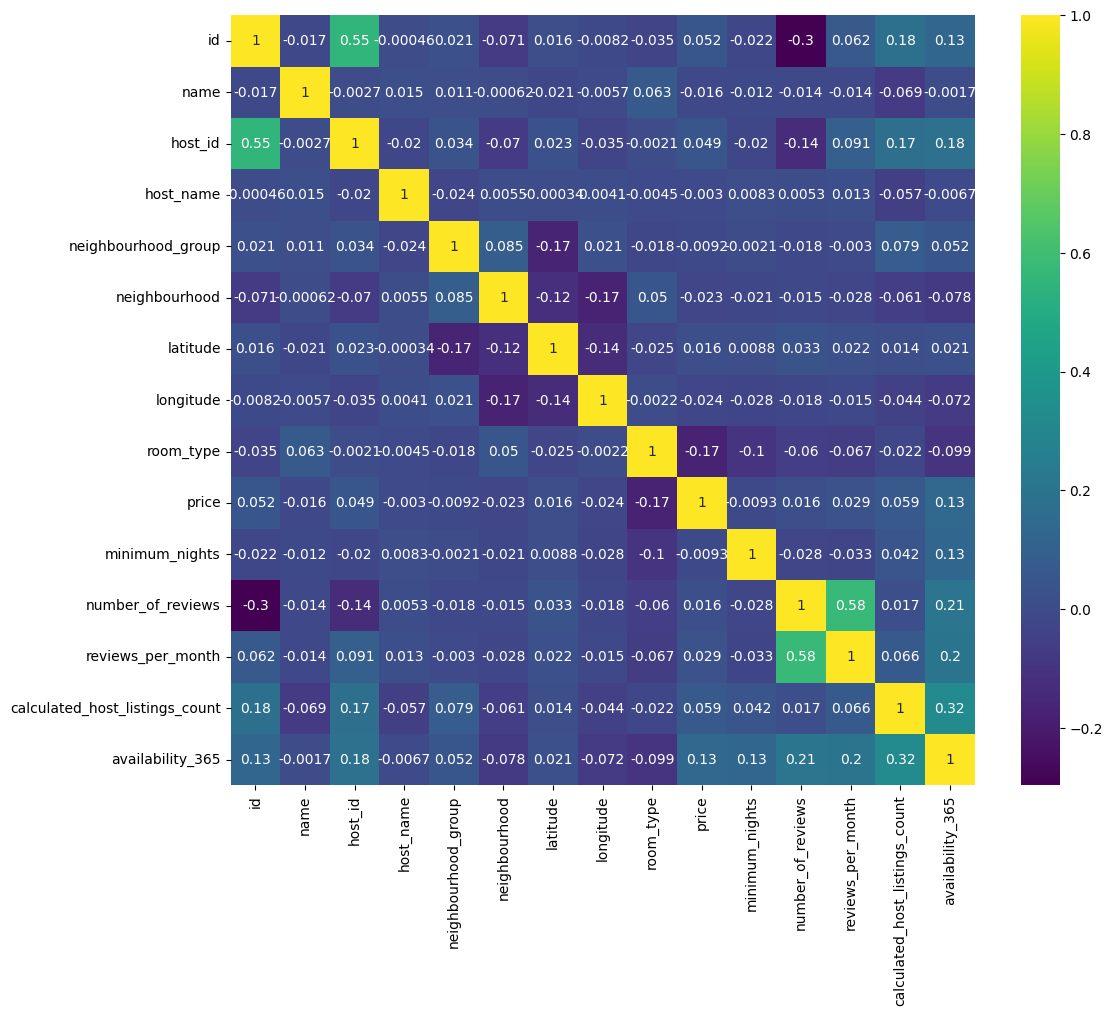

In [ ]:
# Using heatmap to visualize the correlational matrix
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix_normalized, annot=True, cmap='coolwarm')
plt.show()

# Using Pandas scatter_matrix()


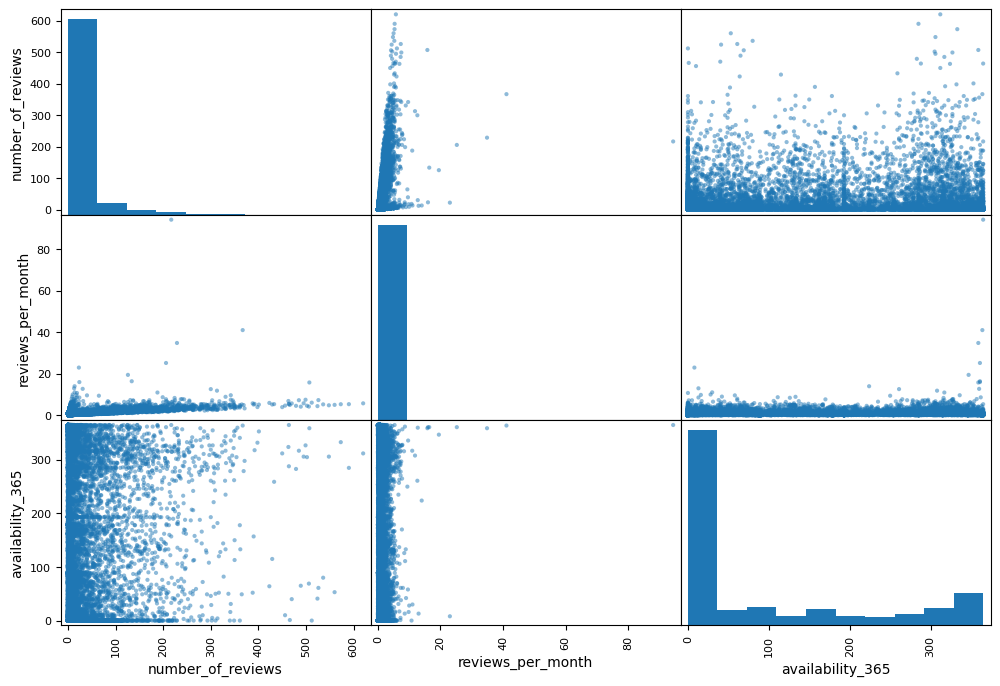

In [ ]:
# We use scatter_matrix from pandas to inspect relationship between 3 numerical attributes, 'number_of_reviews', 'reviews_per_month', 'availability_365'
pd.plotting.scatter_matrix(df_cleaned[['number_of_reviews', 'reviews_per_month', 'availability_365']], figsize=(12, 8))
plt.show()

# Part B: PCA
 ## Task 2
 * Q 1*
 The main motivations for reducing a dataset's dimensionality is to improve computational efficiency, enhance model performance, facilitate in data visualization and noise reduction.

 But it comes with its drawbacks like: Information loss, Interpretability Issues, and Algorithm Complexity.

 The curse of Dimensionality phenomenon refers to the challenges that arises when analyzing high-dimensional data sets. As dimension increses; data becomes sparce, making it harder to identify pattern, the volume of space increases exponentially, requiring more d ata to achieve reliable results.



In [ ]:
import numpy as np
from sklearn.decomposition import PCA
from sklearn.datasets import fetch_openml

# Load the MNIST dataset
mnist = fetch_openml('mnist_784', version = 1)
X = mnist.data
y = mnist.target

# Apply PCA with 95% variance ratio
pca  = PCA(0.95)
X_pca = pca.fit_transform(X)

# Number of dimensions
n_components = X_pca.shape[1]
print(f"Number of dimensions after PCA: {n_components}")


Number of dimensions after PCA: 154


The MINST dataset contains 784 dimensional feature vectors. Applying PCA with 95 % variance ratio, we will have 154 dimensions after PCA.

Reversing the dimensionality after reducing depends on the algorithm applied for dimension reduction. PCA technique is partially reversible. Aftrer reducing dimensions, its possible to approximate the original data using the inverse transformation however this reconstruction is not perfect due to loss of information during reduction process.

**PCA on a 1000-dimensional dataset with 95% variance ratio**
It depends on the intrinsic structure of the data. For dataset with high redundancy, fewer components are needed. In the case of MNIST dataset, which has 784 dimensions, approximately 154 principal components are sufficient to preserve 95% of the variance.
Therefore for a 1000-dimensional dataset, the number of Principal Components required to retain 95% of the variance will probably be slightly higher than 154, depending on the dataset's intrinsic characteristics.